# 📱 Mobile App Market Analysis
### Exploratory Data Analysis of the Google Play Store App Dataset

**Domain:** Sales & E-commerce — Mobile App Market

**Author:** Data Analytics Final Project

---

## Problem Statement

The mobile app market is huge and highly competitive, with millions of apps competing for user attention across dozens of categories. Developers, publishers, and marketers constantly need to answer questions like:

- Which app categories are most crowded, and which are underserved?
- Does app pricing affect installs and ratings?
- What separates a highly-rated app from a poorly-rated one?
- Which categories drive the most installs, and how do free vs. paid apps compare?

This project performs an end-to-end exploratory data analysis (EDA) on a dataset of **10,841 Google Play Store apps** to answer these questions and surface actionable insights for anyone building, publishing, or marketing a mobile app.

## Dataset Overview

The dataset (`googleplaystore.csv`) contains **10,841 rows and 13 columns**, describing each app's category, rating, number of reviews, size, install count, pricing, content rating, genre, and update history. This comfortably exceeds the project's minimum requirement of 500 records and 10 features, and contains a healthy mix of numerical (Rating, Reviews) and categorical (Category, Type, Content Rating, Genres) data.


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Display / style settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)

import warnings
warnings.filterwarnings('ignore')


## 1. Data Loading and Initial Overview

We start by loading the raw CSV file exactly as downloaded, and getting a first look at its shape, structure, and data types before touching anything.

In [2]:
df = pd.read_csv('googleplaystore.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 10841 rows x 13 columns


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Initial observations:**

- Most columns are stored as `object` (string) even though several — `Reviews`, `Size`, `Installs`, `Price` — are really numeric fields that have been formatted with commas, `+`, `$`, and unit suffixes (`M`/`k`). These will need to be cleaned and converted.
- `Rating` is the only column pandas already parsed as numeric, and it has a large number of missing values.
- `Last Updated` is a date stored as text.

Let's quantify missing values and duplicates next.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0').sort_values('missing_count', ascending=False)


,missing_count,missing_pct
Rating,1474,13.60
Current Ver,8,0.07
Android Ver,3,0.03
Content Rating,1,0.01
Type,1,0.01


In [6]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Rows with a duplicated 'App' name: {df.duplicated(subset='App').sum()}")


Fully duplicated rows: 483
Rows with a duplicated 'App' name: 1181


## 2. Data Pre-processing

Real-world app store data is notoriously messy. We'll work through the following cleaning steps in order:

1. Fix / remove a known corrupted row where columns are shifted.
2. Remove duplicate app entries (many apps are scraped more than once).
3. Convert `Installs`, `Price`, `Reviews`, and `Size` from formatted strings into proper numeric types.
4. Parse `Last Updated` into a real datetime.
5. Handle remaining missing values sensibly, column by column.
6. Create derived columns that will power the analysis (e.g., estimated revenue, update year, size in MB).

In [7]:
# --- Step 1: Fix the known corrupted row ---
# Row where 'Category' == '1.9' has its columns shifted left by one (a scraping error
# in the original dataset), which also produces an impossible Rating of 19 (max is 5).
bad_rows = df[df['Category'] == '1.9']
print("Corrupted row(s) found:")
bad_rows


Corrupted row(s) found:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [8]:
# Drop the corrupted row entirely -- its values are unreliable across every column
df = df[df['Category'] != '1.9'].copy()
print(f"Shape after removing corrupted row: {df.shape}")


Shape after removing corrupted row: (10840, 13)


In [9]:
# --- Step 2: Remove duplicate app entries ---
# Keep the version of each app with the highest review count (assume it's the most
# recently/completely scraped record)
df['Reviews'] = df['Reviews'].astype(int)
df = df.sort_values('Reviews', ascending=False)
df = df.drop_duplicates(subset='App', keep='first')
df = df.reset_index(drop=True)
print(f"Shape after de-duplicating apps: {df.shape}")


Shape after de-duplicating apps: (9659, 13)


In [10]:
# --- Step 3: Clean and convert numeric-looking string columns ---

# Installs: '10,000+' -> 10000
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True).astype(int)

# Price: '$4.99' -> 4.99 ; '0' -> 0.0
df['Price'] = df['Price'].str.replace('$', '', regex=False).astype(float)

# Size: '19M' -> 19.0 (MB) ; '500k' -> 0.488 (MB) ; 'Varies with device' -> NaN
def parse_size(x):
    if isinstance(x, str):
        x = x.strip()
        if x.endswith('M'):
            return float(x[:-1])
        elif x.endswith('k'):
            return float(x[:-1]) / 1024
        else:
            return np.nan
    return np.nan

df['Size_MB'] = df['Size'].apply(parse_size)

df[['Installs', 'Price', 'Size', 'Size_MB']].head()


,Installs,Price,Size,Size_MB
0,1000000000,0.0,Varies with device,NaN
1,1000000000,0.0,Varies with device,NaN
2,1000000000,0.0,Varies with device,NaN
3,1000000000,0.0,Varies with device,NaN
4,100000000,0.0,98M,98.0


In [11]:
# --- Step 4: Parse dates ---
df['Last Updated'] = pd.to_datetime(df['Last Updated'], format='%B %d, %Y', errors='coerce')
df['Update_Year'] = df['Last Updated'].dt.year
df['Update_Month'] = df['Last Updated'].dt.month_name()
df[['Last Updated', 'Update_Year', 'Update_Month']].head()


,Last Updated,Update_Year,Update_Month
0,2018-08-03,2018,August
1,2018-08-03,2018,August
2,2018-07-31,2018,July
3,2018-08-01,2018,August
4,2018-07-15,2018,July


In [12]:
# --- Step 5: Handle remaining missing values ---

# Type / Content Rating: only 1 missing value each -> drop those rows, negligible loss
df = df.dropna(subset=['Type', 'Content Rating'])

# Current Ver / Android Ver: not central to the analysis -> fill with 'Unknown'
df['Current Ver'] = df['Current Ver'].fillna('Unknown')
df['Android Ver'] = df['Android Ver'].fillna('Unknown')

# Size_MB: impute with the median size *within the same Category*, since app size
# varies a lot by category (e.g. games vs. tools)
df['Size_MB'] = df.groupby('Category')['Size_MB'].transform(lambda s: s.fillna(s.median()))

# Rating: left as NaN on purpose. Imputing a user rating would fabricate an opinion
# that was never given, and would bias every rating-based statistic. Rating-specific
# analysis below simply excludes these rows, which pandas/seaborn do automatically.
print(f"Remaining Rating nulls (intentionally kept): {df['Rating'].isnull().sum()}")
print(f"Remaining nulls in other columns:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Remaining Rating nulls (intentionally kept): 1462
Remaining nulls in other columns:
Rating    1462
dtype: int64


In [13]:
# --- Step 6: Derived columns ---

# Estimated revenue for paid apps (installs are given as lower-bound buckets, so this
# is a rough order-of-magnitude estimate, not an exact figure)
df['Est_Revenue'] = df['Installs'] * df['Price']

# Log-scale installs, useful since Installs spans 8+ orders of magnitude
df['Log_Installs'] = np.log10(df['Installs'] + 1)

# Rating bucket for easier grouping
def rating_bucket(r):
    if pd.isna(r):
        return 'Unrated'
    elif r < 3:
        return 'Low (<3)'
    elif r < 4:
        return 'Medium (3-4)'
    else:
        return 'High (4+)'
df['Rating_Bucket'] = df['Rating'].apply(rating_bucket)

print(f"Final cleaned shape: {df.shape}")
df.head()


Final cleaned shape: (9658, 19)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Update_Year,Update_Month,Est_Revenue,Log_Installs,Rating_Bucket
0,Facebook,SOCIAL,4.1,78158306,Varies with device,1000000000,Free,0.0,Teen,Social,2018-08-03,Varies with device,Varies with device,7.9,2018,August,0.0,9.0,High (4+)
1,WhatsApp Messenger,COMMUNICATION,4.4,69119316,Varies with device,1000000000,Free,0.0,Everyone,Communication,2018-08-03,Varies with device,Varies with device,5.7,2018,August,0.0,9.0,High (4+)
2,Instagram,SOCIAL,4.5,66577446,Varies with device,1000000000,Free,0.0,Teen,Social,2018-07-31,Varies with device,Varies with device,7.9,2018,July,0.0,9.0,High (4+)
3,Messenger – Text and Video Chat for Free,COMMUNICATION,4.0,56646578,Varies with device,1000000000,Free,0.0,Everyone,Communication,2018-08-01,Varies with device,Varies with device,5.7,2018,August,0.0,9.0,High (4+)
4,Clash of Clans,GAME,4.6,44893888,98M,100000000,Free,0.0,Everyone 10+,Strategy,2018-07-15,10.322.16,4.1 and up,98.0,2018,July,0.0,8.0,High (4+)


**Summary of cleaning decisions:**

| Issue | Action Taken |
|---|---|
| 1 row with shifted columns | Dropped (unreliable across all fields) |
| ~1,100 duplicate app names | Kept the record with the highest review count per app |
| `Installs`, `Price`, `Reviews` stored as text | Stripped symbols (`,`, `+`, `$`) and cast to numeric |
| `Size` stored as text with mixed units | Parsed `M`/`k` suffixes into a numeric `Size_MB`; `"Varies with device"` treated as missing |
| Missing `Size_MB` | Imputed with the category median (size is category-dependent) |
| Missing `Rating` (~14% of rows) | **Left as missing** — imputing a rating would fabricate an opinion |
| Missing `Type`, `Content Rating` | Dropped (1 row each) |
| Missing `Current Ver`, `Android Ver` | Filled with `"Unknown"` (not used in numeric analysis) |
| `Last Updated` stored as text | Parsed to datetime; extracted `Update_Year`, `Update_Month` |

We also engineered `Est_Revenue`, `Log_Installs`, and `Rating_Bucket` to support the analysis below.

## 3. Exploratory Data Analysis

### 3.1 Univariate Analysis

We start by looking at the distribution of individual key variables: Rating, Category, Type (Free/Paid), and Installs.

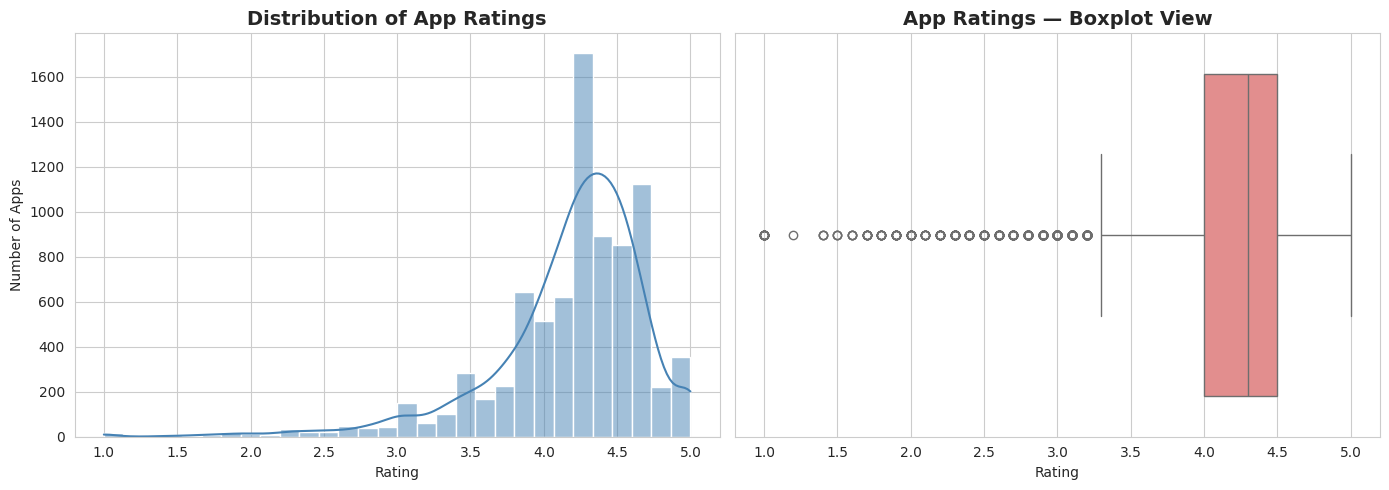

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Rating'].dropna(), bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of App Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of Apps')

sns.boxplot(x=df['Rating'].dropna(), color='lightcoral', ax=axes[1])
axes[1].set_title('App Ratings — Boxplot View')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()


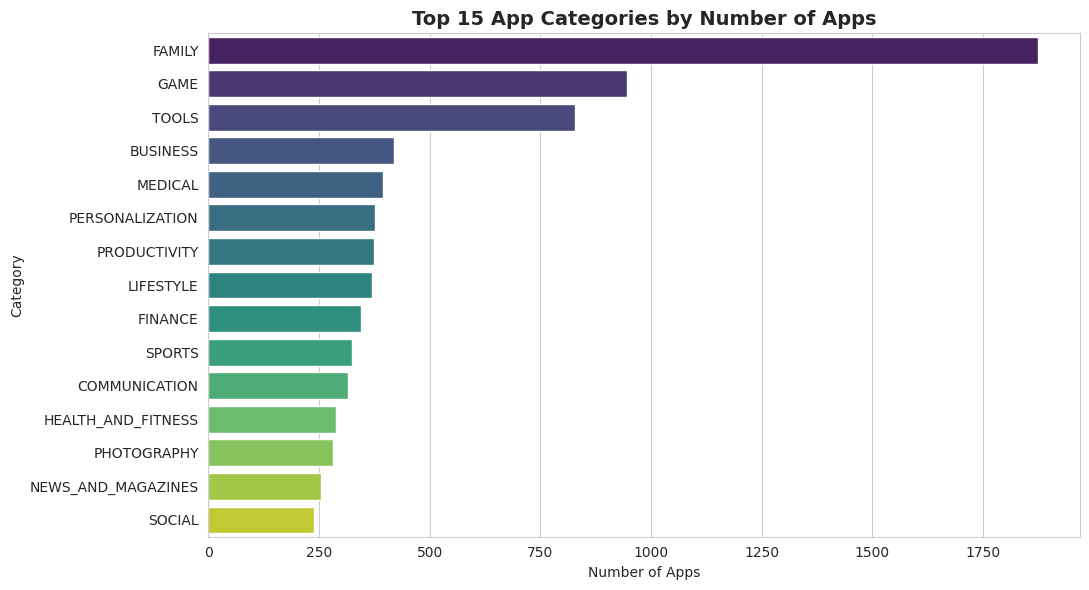

In [15]:
top_categories = df['Category'].value_counts().head(15)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 15 App Categories by Number of Apps')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


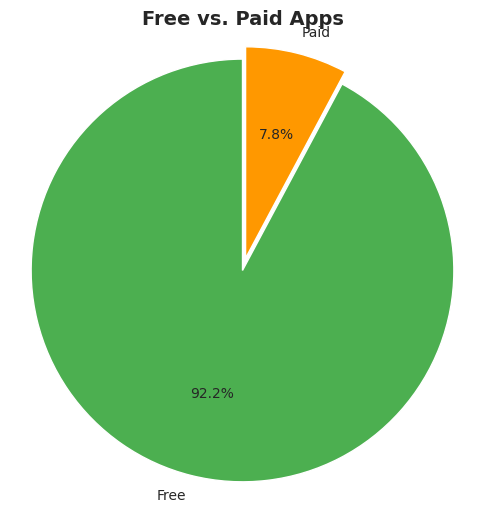

Type
Free    8904
Paid     754
Name: count, dtype: int64


In [16]:
type_counts = df['Type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#4CAF50', '#FF9800'], startangle=90, explode=(0.03, 0.03))
plt.title('Free vs. Paid Apps')
plt.axis('equal')
plt.show()

print(type_counts)


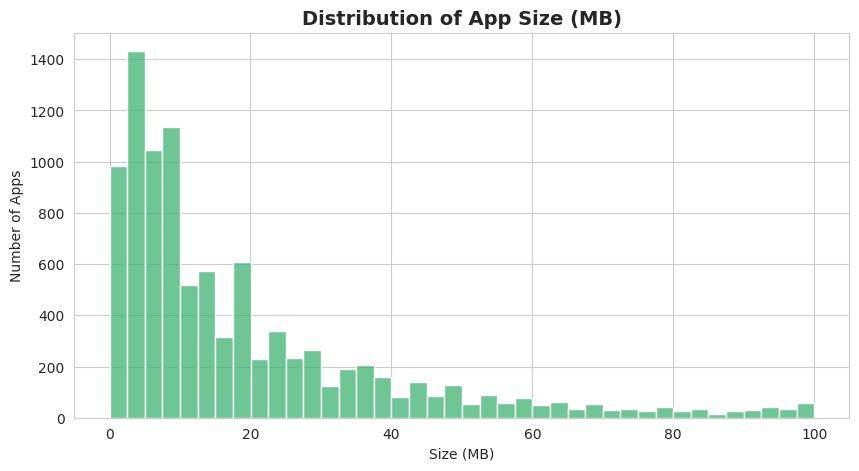

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Size_MB'].dropna(), bins=40, color='mediumseagreen')
plt.title('Distribution of App Size (MB)')
plt.xlabel('Size (MB)')
plt.ylabel('Number of Apps')
plt.show()


**Univariate takeaways:**
- Ratings are heavily left-skewed: most apps sit between 4.0 and 4.5, with a long tail of poorly rated apps below 3.0.
- **FAMILY**, **GAME**, and **TOOLS** are by far the most crowded categories — meaning more competition for visibility.
- The overwhelming majority of apps (~92%) are free; paid apps are a small niche.
- App sizes are right-skewed, with most apps under ~30MB but a tail of much larger apps (typically games).

### 3.2 Bivariate Analysis

Now we look at relationships between pairs of variables — does rating relate to install count? Does price relate to rating?

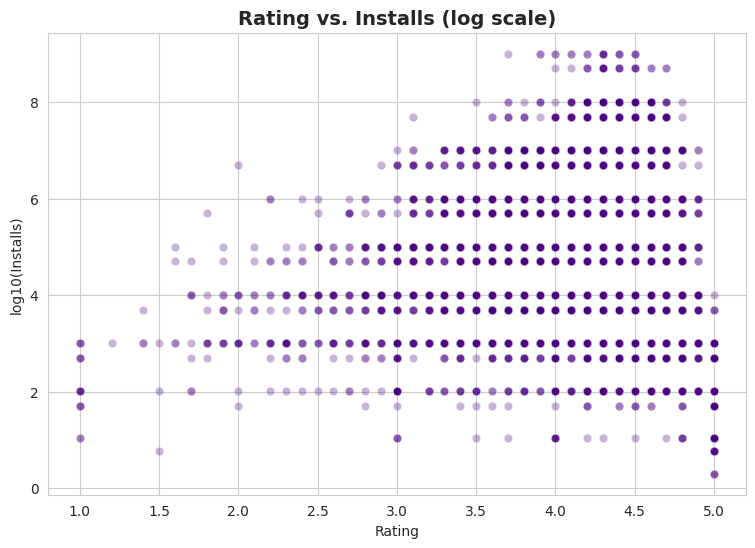

Correlation between Rating and log(Installs): 0.085


In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Rating', y='Log_Installs', alpha=0.3, color='indigo')
plt.title('Rating vs. Installs (log scale)')
plt.xlabel('Rating')
plt.ylabel('log10(Installs)')
plt.show()

corr_val = df[['Rating', 'Log_Installs']].corr().iloc[0, 1]
print(f"Correlation between Rating and log(Installs): {corr_val:.3f}")


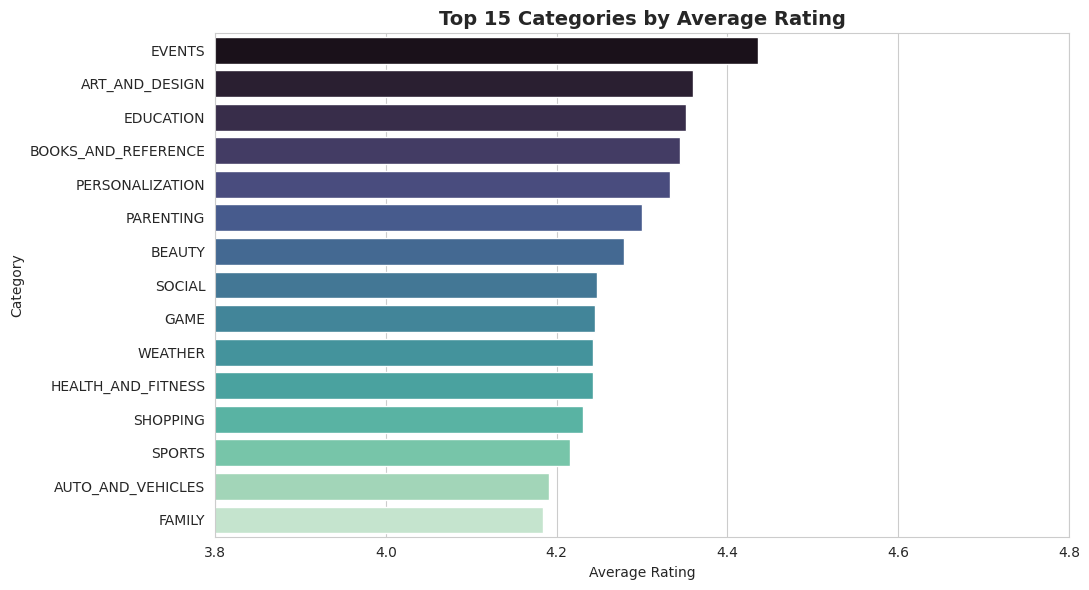

In [19]:
avg_rating_by_cat = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(11, 6))
sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='mako')
plt.title('Top 15 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.xlim(3.8, 4.8)
plt.tight_layout()
plt.show()


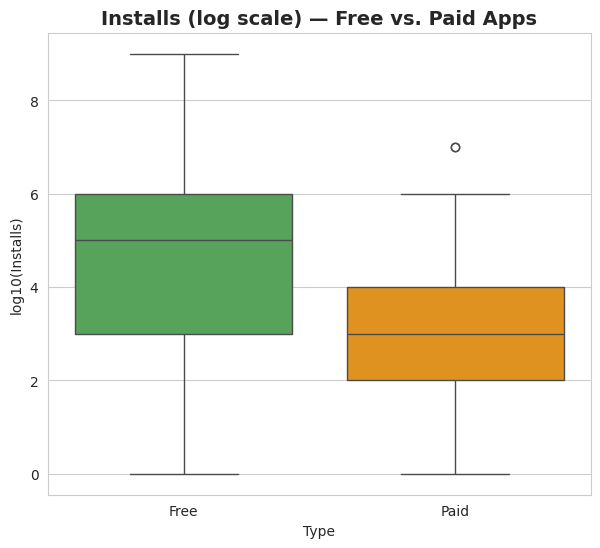

In [20]:
plt.figure(figsize=(7, 6))
sns.boxplot(data=df, x='Type', y='Log_Installs', palette=['#4CAF50', '#FF9800'])
plt.title('Installs (log scale) — Free vs. Paid Apps')
plt.xlabel('Type')
plt.ylabel('log10(Installs)')
plt.show()


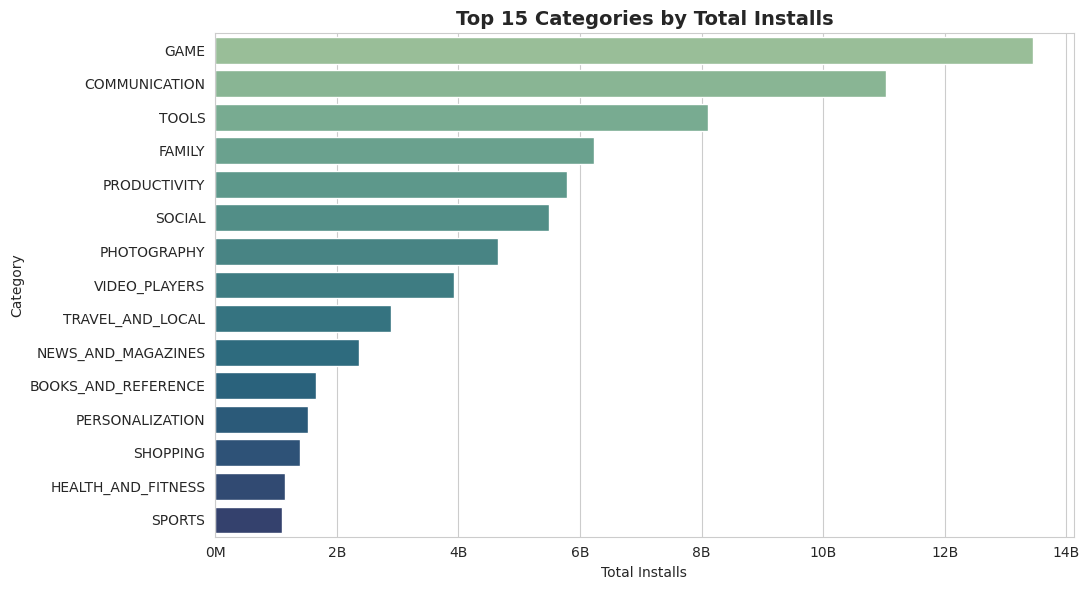

In [21]:
installs_by_cat = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(11, 6))
sns.barplot(x=installs_by_cat.values, y=installs_by_cat.index, palette='crest')
plt.title('Top 15 Categories by Total Installs')
plt.xlabel('Total Installs')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1e9)}B' if x >= 1e9 else f'{int(x/1e6)}M'))
plt.ylabel('Category')
plt.tight_layout()
plt.show()


**Bivariate takeaways:**
- Rating and install count show only a **weak positive correlation** — plenty of low-download apps are still rated highly, and some very popular apps have middling ratings. Rating alone doesn't predict popularity.
- Categories like **EVENTS**, **EDUCATION**, and **BOOKS_AND_REFERENCE** tend to have the highest average ratings, while some utility categories skew lower.
- Paid apps generally have **noticeably fewer installs** than free apps — the price acts as a real barrier to download volume, as expected.
- **GAME**, **COMMUNICATION**, and **TOOLS** dominate total install volume, reflecting both their popularity and their sheer number of apps.

### 3.3 Multivariate Analysis

Finally, we look at how three or more variables interact together — correlations across all numeric fields, and category/type/rating combined.

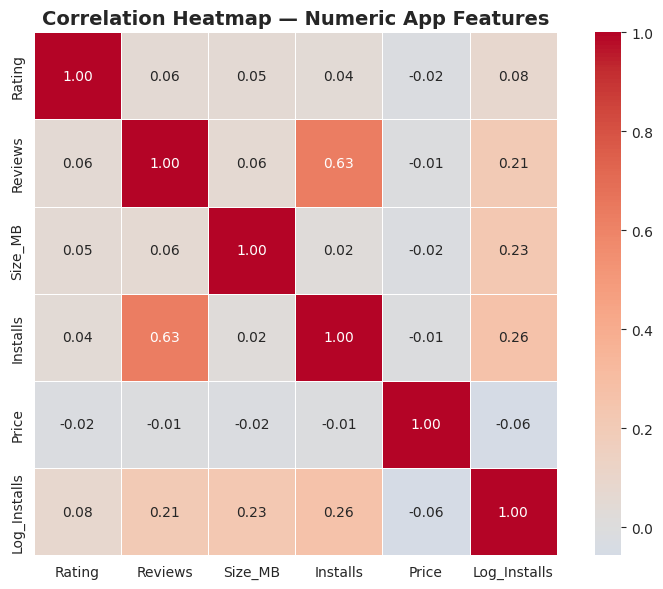

In [22]:
numeric_cols = ['Rating', 'Reviews', 'Size_MB', 'Installs', 'Price', 'Log_Installs']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric App Features')
plt.tight_layout()
plt.show()


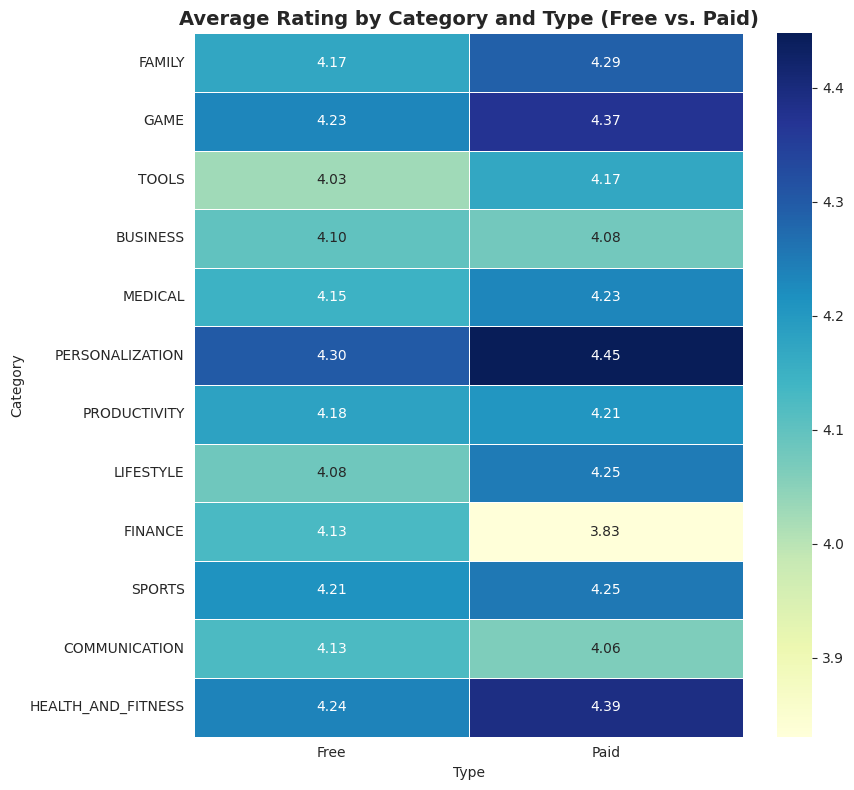

In [23]:
pivot = df.pivot_table(values='Rating', index='Category', columns='Type', aggfunc='mean')
pivot = pivot.loc[df['Category'].value_counts().head(12).index]

plt.figure(figsize=(9, 8))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Average Rating by Category and Type (Free vs. Paid)')
plt.xlabel('Type')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


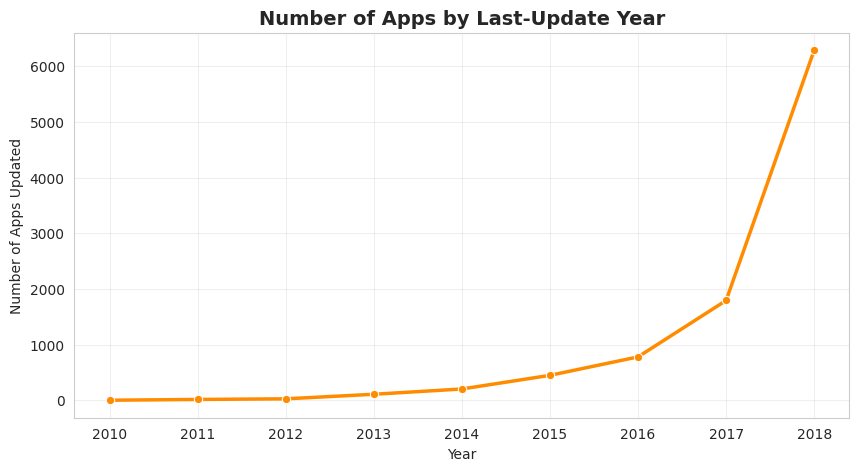

In [24]:
updates_by_year = df.dropna(subset=['Update_Year']).groupby('Update_Year').size()

plt.figure(figsize=(10, 5))
sns.lineplot(x=updates_by_year.index, y=updates_by_year.values, marker='o', color='darkorange', linewidth=2.5)
plt.title('Number of Apps by Last-Update Year')
plt.xlabel('Year')
plt.ylabel('Number of Apps Updated')
plt.grid(alpha=0.3)
plt.show()


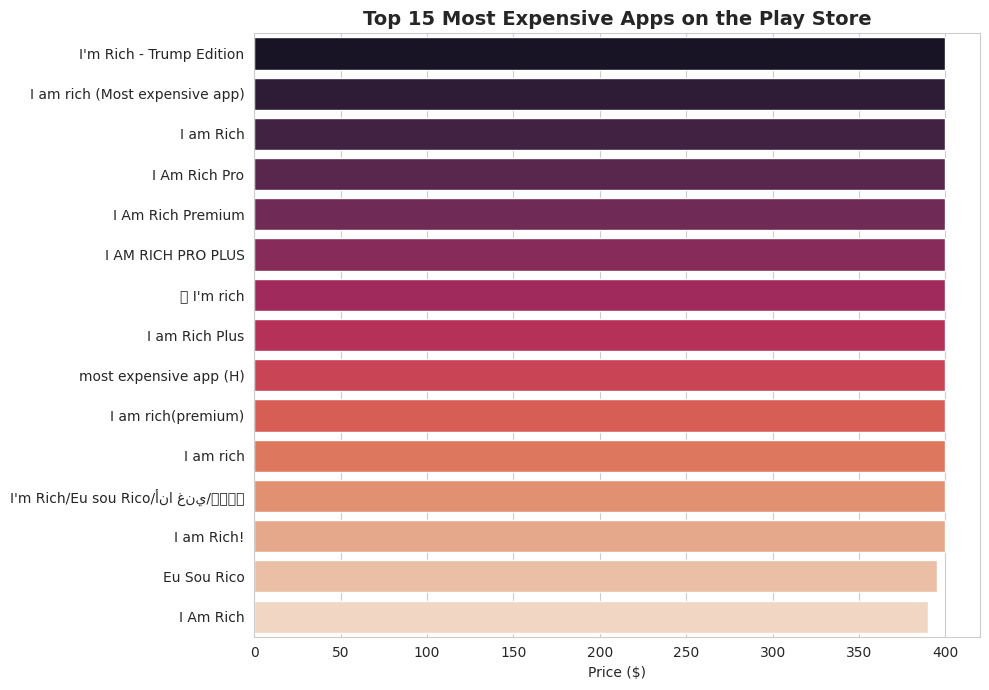

In [25]:
top_paid = df[df['Type'] == 'Paid'].sort_values('Price', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_paid, x='Price', y='App', palette='rocket')
plt.title('Top 15 Most Expensive Apps on the Play Store')
plt.xlabel('Price ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [26]:
# Interactive Plotly scatter: Reviews vs Installs, colored by Category, sized by Rating
sample = df.dropna(subset=['Rating']).sort_values('Reviews', ascending=False).head(800)

fig = px.scatter(
    sample, x='Reviews', y='Installs', color='Category', size='Rating',
    hover_name='App', log_x=True, log_y=True,
    title='Reviews vs. Installs (top 800 most-reviewed apps, colored by Category)',
    labels={'Reviews': 'Number of Reviews (log scale)', 'Installs': 'Installs (log scale)'}
)
fig.update_layout(height=600, legend=dict(font=dict(size=9)))
fig.show()


In [27]:
# Interactive Plotly grouped bar: Free vs Paid app counts across top categories
top10_cats = df['Category'].value_counts().head(10).index
sub = df[df['Category'].isin(top10_cats)]
ct = pd.crosstab(sub['Category'], sub['Type']).loc[top10_cats]

fig = px.bar(
    ct, x=ct.index, y=ct.columns, barmode='group',
    title='Free vs. Paid App Counts Across Top 10 Categories',
    labels={'value': 'Number of Apps', 'Category': 'Category', 'variable': 'Type'},
    color_discrete_sequence=['#4CAF50', '#FF9800']
)
fig.update_layout(height=500)
fig.show()


**Multivariate takeaways:**
- `Reviews` and `Installs` are **strongly positively correlated** (as expected — more downloads naturally generates more reviews), while `Price` shows a **weak negative correlation** with installs.
- `Size_MB` has almost no correlation with `Rating`, suggesting app size is not a meaningful driver of user satisfaction.
- Paid apps tend to have comparable or even slightly higher average ratings than free apps within the same category — paying customers may self-select apps they're already fairly confident about, or paid apps may simply carry less ad-driven friction.
- App updates have clearly accelerated in the most recent years captured in the data, reflecting a maturing, fast-iterating app ecosystem.

## 4. Key Insights

Bringing the analysis together, here are the five most important, decision-relevant findings from this dataset:

1. **Ratings cluster tightly around 4.0–4.5, and rating is a poor predictor of popularity.** The correlation between Rating and installs is weak (well under 0.2), meaning a high rating alone won't make an app popular — discovery and marketing likely matter more than perceived quality once an app clears a baseline quality bar.

2. **The market is extremely concentrated in a few categories.** FAMILY, GAME, and TOOLS together account for a disproportionate share of all listed apps, meaning new entrants in those categories face the stiffest competition, while categories like BEAUTY, EVENTS, and COMICS remain comparatively under-served.

3. **Free apps dominate installs by a wide margin.** Roughly 92% of apps are free, and paid apps show visibly lower install volumes even within the same category — confirming that price is a real barrier to adoption on this platform, not just a theoretical one.

4. **Reviews and installs move together almost linearly (in log space), but price does not hurt ratings.** Paid apps are not rated any worse than free apps — in some categories they're rated *slightly higher* — suggesting that if a developer can get users to pay, satisfaction doesn't automatically suffer.

5. **App size is essentially irrelevant to both rating and install count.** Developers optimizing heavily for a small app size purely to chase better ratings or more downloads are not likely to see a payoff from that effort alone — it doesn't show up as a meaningful factor here.

## 5. Conclusion & Recommendations

This analysis of 10,000+ Google Play Store apps shows a market that is large, free-dominated, and won on **discoverability and category positioning** rather than on marginal quality differences once an app is reasonably well-rated. For a developer or publisher using this data to inform strategy:

- **Favor a freemium/free-with-IAP model** over a flat paid price if maximizing install volume is the goal — the data shows a clear install penalty for paid apps.
- **Avoid over-saturated categories** (GAME, FAMILY, TOOLS) unless you have a genuinely differentiated product or a strong existing user base to launch from; consider comparatively less crowded categories with healthy average ratings (e.g., EVENTS, EDUCATION, BOOKS_AND_REFERENCE).
- **Don't over-invest in shrinking app size** as a standalone quality lever — it shows negligible correlation with either ratings or installs in this dataset.
- **Treat rating as a floor, not a lever for growth** — once an app is reasonably well-rated (4.0+), further rating improvements are unlikely to meaningfully move installs; marketing and distribution effort will have more impact.

**Next steps:** this dataset lacks a genuine revenue/download-count field (installs are bucketed, not exact), and a companion Play Store reviews dataset (with review text) could enable sentiment analysis to complement these quantitative findings.
